In [10]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from enum import Enum

In [ ]:
#Whichever index prints as available is your continuity camera
for i in range(5):
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"Camera {i} is available")
        cap.release()

[/Users/build/sandbox/BuildRepos/Sol-Windows-2/External/VirtualMonitor-macOS/MersiveRelayCam/RelayPlugin/VtcComLib/VtcComLib.cpp] initializer()
[/Users/build/sandbox/BuildRepos/Sol-Windows-2/External/VirtualMonitor-macOS/MersiveRelayCam/RelayPlugin/avCam/avCam/avCamLib.mm] initializer()


2025-11-06 17:52:44.001 python[1999:25335] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Camera 0 is available
Camera 1 is available
Camera 2 is available
Camera 3 is available


OpenCV: out device of bound (0-3): 4
OpenCV: camera failed to properly initialize!


In [ ]:
# Initialize the camera
# Replace 2 with your given camera index
cap = cv2.VideoCapture(2)

if not cap.isOpened():
    print("Error: Could not open Continuity Camera.")
else:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        cv2.imshow("Continuity Camera Feed", frame)

        # Press 'c' to capture a photo
        if cv2.waitKey(1) & 0xFF == ord('c'):
            cv2.imwrite("sample_image.jpg", frame)
            print("Photo saved as sample_image.jpg")

        # Press 'q' to quit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

Photo saved as sample_image.jpg


## Sample Workflow for Demo (Image Capture -> Corner Detection -> Outputted Coordinates)

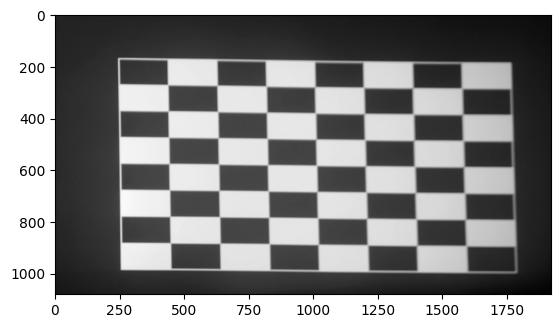

In [17]:
image_path = "sample_image.jpg"
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

In [18]:
class Corner(Enum):
    TOP_RIGHT = 0;
    BOTTOM_RIGHT = 1;
    TOP_LEFT = 2;
    BOTTOM_LEFT = 3;

In [19]:
def getTopLeft(corner_i, corners, pattern_size):
    x = [corners[i][0][0] for i in corner_i];
    y = [corners[i][0][1] for i in corner_i];
    
    # Finds the indices with the two smallest values of x and y.
    two_xlowest = np.argpartition(x, 2 - 1);
    two_ylowest = np.argpartition(y, 2 - 1);
    
    top_left = two_xlowest[0]; # Find index that is in the bottom 2 values of both x and y.
    if (two_ylowest[0] != top_left and two_ylowest[1] != top_left):
        top_left = two_xlowest[1];

    return top_left;

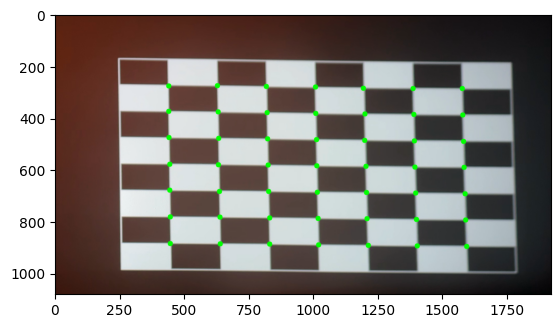

In [26]:
# image_path = "corners1.jpg"
image_path = "sample_image.jpg"
# image_path = "uptilt_cb.jpg"
# image_path = "rotate_cb.jpg"

pattern_size = (8-1, 8-1)

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, corners = cv2.findChessboardCorners(gray, pattern_size)

cornercheck = [
     0, 1, pattern_size[0], pattern_size[0]+1,
     pattern_size[0] - 1, pattern_size[0] - 2, 2*pattern_size[0] - 1, 2*pattern_size[0] - 2,
     len(corners)-1, len(corners) - 2, len(corners) - pattern_size[0] - 1, len(corners) - pattern_size[0] - 2,
     len(corners) - pattern_size[0], len(corners) - pattern_size[0] + 1, len(corners) - 2*pattern_size[0], len(corners) - 2*pattern_size[0] + 1
              ]
# cornercheck = c

# Order of Corners: Always counterclockwise
if ret: # Corners exist
    for i in range(len(corners)):
        # if (i not in cornercheck):
        #     continue;
        x = int(corners[i][0][0])
        y = int(corners[i][0][1])
        cv2.circle(img, (x, y), 10, (0, 255, 0), -1)

plt.imshow(img)

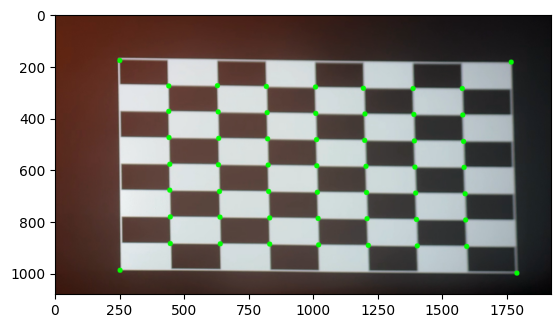

In [27]:
# Find which index is the top-left corner.
corner_i = [0, pattern_size[0] - 1, len(corners)-1, len(corners) - pattern_size[0]]
top_left = getTopLeft(corner_i, corners, pattern_size);

# 2D array then rotate corners matrix to get top-left corner to (0,0)
corners = corners.reshape((pattern_size[0], pattern_size[1], 2));
if(top_left == 3): k = -1; # k=-1 for clockwise 90 degrees.
elif(top_left == 2): k = -2; # 180 degrees.
elif(top_left == 1): k = -3; # clockwise 270 degrees.
else: k = 0;
corners = np.rot90(corners, k);

# Corner detection gets more inaccurate as the distortion gets more extreme.
top_left = corners[0, 0] - (corners[0,1] - corners[0,0]) - (corners[1,0] - corners[0,0])
top_right = corners[0, -1] - (corners[0,-2] - corners[0,-1]) - (corners[1,-1] - corners[0,-1])
bottom_left = corners[-1, 0] - (corners[-2,0] - corners[-1, 0]) - (corners[-1, 1] - corners[-1, 0])
bottom_right = corners[-1, -1] - (corners[-2, -1] - corners[-1,-1]) - (corners[-1,-2] - corners[-1,-1])


for corner in [top_left, top_right, bottom_left, bottom_right]:
    x = int(corner[0]);
    y = int(corner[1]);
    cv2.circle(img, (x,y), 10, (0, 255, 0), -1)

plt.imshow(img)